# II. customers.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

def find_project_root(start_path=None):
    start_path = Path.cwd().resolve() if start_path is None else Path(start_path).resolve()
    for path in [start_path, *start_path.parents]:
        if (path / 'data' / 'raw').exists():
            return path
    raise FileNotFoundError('Cannot find project root containing data/raw')

ROOT_DIR = find_project_root()
DATA_RAW_PATH = ROOT_DIR / 'data' / 'raw'
IMAGES_DIR = ROOT_DIR / 'notebooks' / 'basic eda' / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Data path: {DATA_RAW_PATH}')

def load_customers_data():
    customers = pd.read_csv(DATA_RAW_PATH / 'customers.csv', parse_dates=['signup_date'])
    customers['signup_year'] = customers['signup_date'].dt.year
    customers['signup_month'] = customers['signup_date'].dt.month
    return customers

customers_df = load_customers_data()

Data path: D:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


## 1. Tổng quan

In [ ]:
customers_df.head(10)

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel,signup_year,signup_month
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media,2021,12
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign,2013,12
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search,2018,7
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral,2017,11
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search,2022,9
5,6,15202,Phu Ly,2022-04-14,Female,25-34,organic_search,2022,4
6,8,15202,Phu Ly,2015-09-11,Male,45-54,social_media,2015,9
7,9,15202,Phu Ly,2020-02-14,Male,35-44,email_campaign,2020,2
8,10,15202,Phu Ly,2014-03-03,Male,25-34,organic_search,2014,3
9,11,15203,Viet Tri,2017-11-07,Male,35-44,organic_search,2017,11


In [ ]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          121930 non-null  int64         
 1   zip                  121930 non-null  int64         
 2   city                 121930 non-null  object        
 3   signup_date          121930 non-null  datetime64[ns]
 4   gender               121930 non-null  object        
 5   age_group            121930 non-null  object        
 6   acquisition_channel  121930 non-null  object        
 7   signup_year          121930 non-null  int32         
 8   signup_month         121930 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(2), object(4)
memory usage: 7.4+ MB


In [ ]:
customers_df.columns

Index(['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group',
       'acquisition_channel', 'signup_year', 'signup_month'],
      dtype='object')

In [ ]:
customers_df.shape

(121930, 9)

### 1.1. Phân tích đơn biến

### 1.1.1. Biến số

#### a. Phân phối và outliers

In [7]:
customers_df.columns

Index(['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group',
       'acquisition_channel', 'signup_year', 'signup_month'],
      dtype='object')

Da luu bieu do ket hop tai: D:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\notebooks\basic eda\images\customers_distribution_boxplot.png


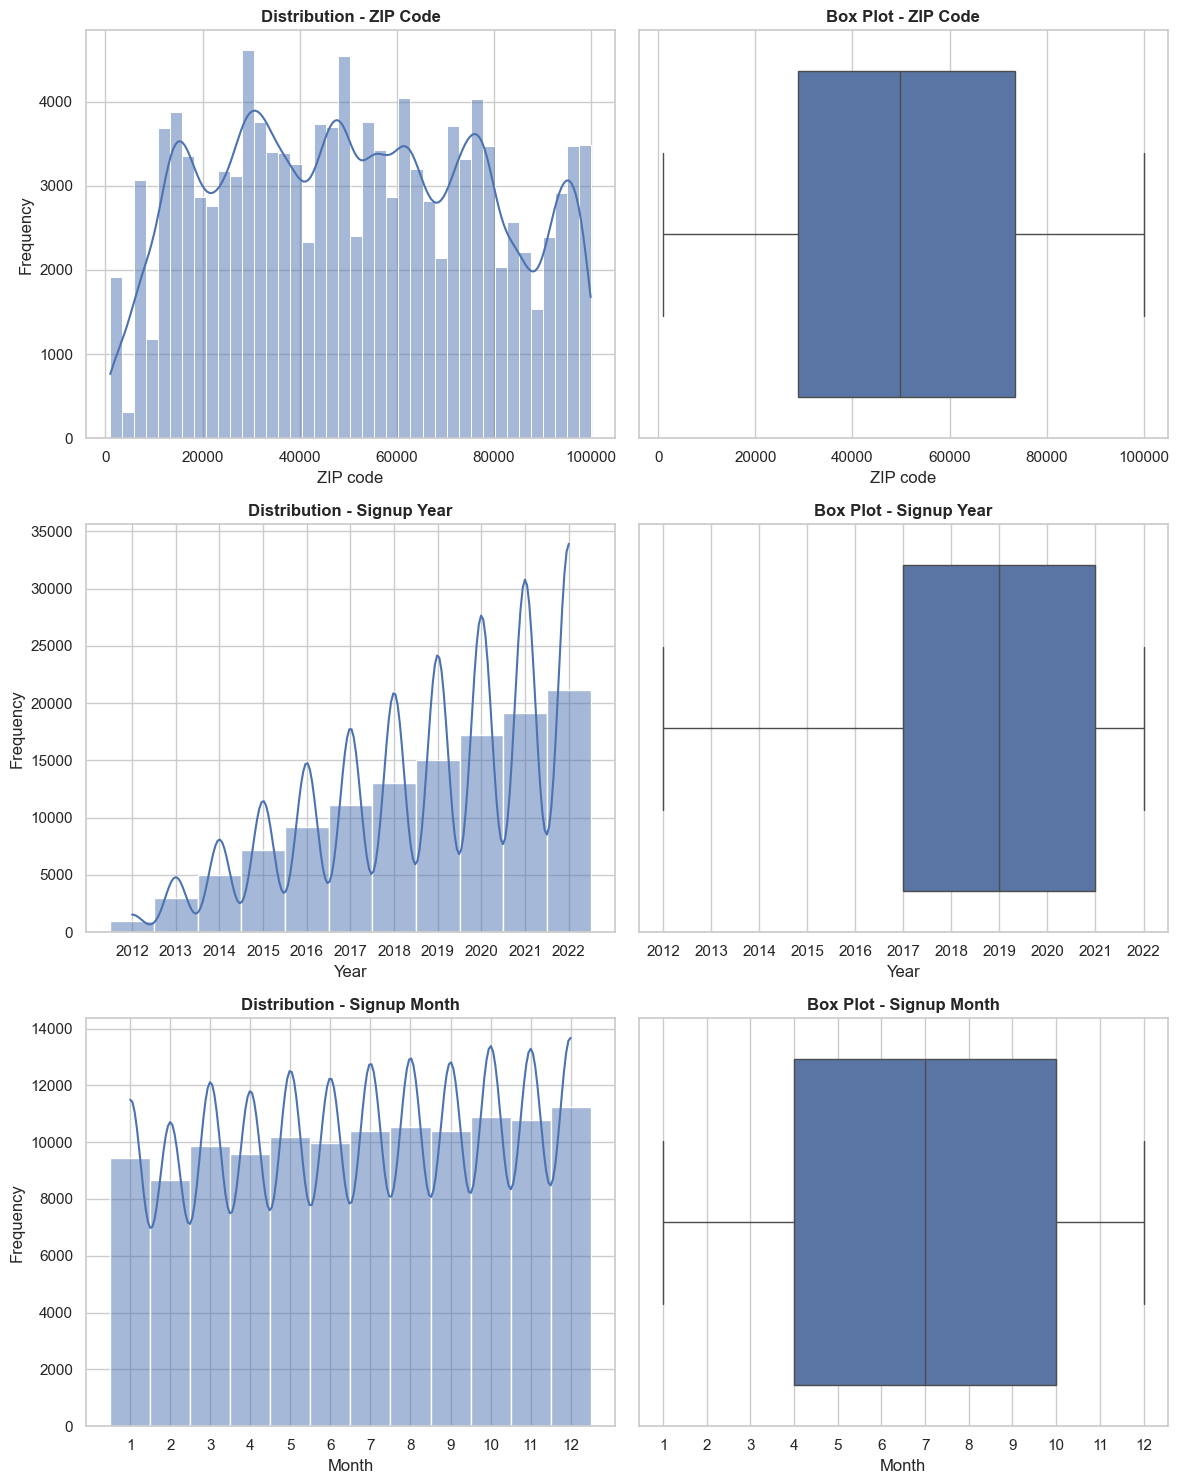

In [13]:
col_config = {
    'zip': {
        'title': 'ZIP Code',
        'xlabel': 'ZIP code',
        'hist_kwargs': {'bins': 40}
    },
    'signup_year': {
        'title': 'Signup Year',
        'xlabel': 'Year',
        'hist_kwargs': {'discrete': True}
    },
    'signup_month': {
        'title': 'Signup Month',
        'xlabel': 'Month',
        'hist_kwargs': {'discrete': True}
    }
}

con_cols_names = ['zip', 'signup_year', 'signup_month']

def format_axis(ax, col_name, values):
    if col_name == 'signup_year':
        ax.set_xticks(sorted(values.unique()))
    elif col_name == 'signup_month':
        ax.set_xticks(range(1, 13))

def plot_distribution(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    plt.figure(figsize=(6 * cols, 5 * rows))

    for i, col_name in enumerate(con_cols_names, 1):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Value', 'hist_kwargs': {}})
        ax = plt.subplot(rows, cols, i)
        values = df[col_name].dropna()
        sns.histplot(values, kde=True, ax=ax, **cfg.get('hist_kwargs', {}))
        ax.set_title(f"Distribution - {cfg['title']}", fontweight='bold')
        ax.set_xlabel(cfg['xlabel'])
        ax.set_ylabel('Frequency')
        format_axis(ax, col_name, values)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do phan phoi tai: {save_path}')

    plt.show()

def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    plt.figure(figsize=(12, 5 * n))

    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Value', 'hist_kwargs': {}})
        values = df[col_name].dropna()

        ax1 = plt.subplot(n, 2, 2 * i + 1)
        sns.histplot(values, kde=True, ax=ax1, **cfg.get('hist_kwargs', {}))
        ax1.set_title(f"Distribution - {cfg['title']}", fontweight='bold')
        ax1.set_xlabel(cfg['xlabel'])
        ax1.set_ylabel('Frequency')
        format_axis(ax1, col_name, values)

        ax2 = plt.subplot(n, 2, 2 * i + 2)
        sns.boxplot(x=values, ax=ax2)
        ax2.set_title(f"Box Plot - {cfg['title']}", fontweight='bold')
        ax2.set_xlabel(cfg['xlabel'])
        format_axis(ax2, col_name, values)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do ket hop tai: {save_path}')

    plt.show()

# plot_distribution(
#     customers_df,
#     con_cols_names,
#     save_path=IMAGES_DIR / 'customers_distribution_plot.png'
# )

plot_distribution_boxplot(
    customers_df,
    con_cols_names,
    save_path=IMAGES_DIR / 'customers_distribution_boxplot.png'
)

Nhận xét:

- Quan sát:
  - Mã ZIP trải rộng gần như toàn bộ khoảng từ 1,001 đến 99,950, trung vị ở mức 49,835 và IQR khá lớn (28,689 - 73,488). Histogram cho thấy dữ liệu phân bổ rộng với nhiều cụm nhẹ, nhưng boxplot không xuất hiện outliers dị biệt rõ ràng.
  - Năm đăng ký tập trung mạnh vào các năm gần đây. Trung vị là 2019, 50% khách hàng nằm trong giai đoạn 2017 - 2021, và tần suất tăng dần rõ rệt từ 957 khách hàng năm 2012 lên 21,103 khách hàng năm 2022.
  - Tháng đăng ký khá đồng đều giữa 12 tháng nhưng có xu hướng nhích lên vào cuối năm. Tháng 12 cao nhất với 11,228 khách hàng, trong khi tháng 2 thấp nhất với 8,681 khách hàng.

- Insights:
  - `zip` là biến số có kiểu numeric nhưng bản chất là mã vị trí, nên phù hợp để map sang vùng hoặc địa phương hơn là dùng trực tiếp như một biến liên tục trong mô hình.
  - Phân phối của `signup_year` cho thấy tệp khách hàng mở rộng rất nhanh ở giai đoạn gần đây; các phân tích cohort hoặc retention sau này cần lưu ý sự chênh lệch quy mô mạnh giữa cohort cũ và cohort mới.
  - Tính mùa vụ theo tháng có tồn tại nhưng không quá cực đoan; khác biệt chủ yếu là Q4 cao hơn đầu năm, gợi ý cuối năm có thể là giai đoạn thuận lợi hơn cho hoạt động acquisition.

#### b. Thống kê mô tả

In [9]:
nums_cols = ['zip', 'signup_year', 'signup_month']
customers_df[nums_cols].describe()

,zip,signup_year,signup_month
count,121930.00,121930.00,121930.00
mean,50990.17,2018.82,6.71
std,26871.91,2.58,3.44
min,1001.00,2012.00,1.00
25%,28689.25,2017.00,4.00
50%,49835.00,2019.00,7.00
75%,73488.00,2021.00,10.00
max,99950.00,2022.00,12.00


### 1.1.2. Biến thời gian

Thang cao nhat: 2022-12 voi 1,883 khach hang
Thang thap nhat: 2012-01 voi 2 khach hang
Da luu bieu do xu huong tai: D:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\notebooks\basic eda\images\customers_signup_trend.png


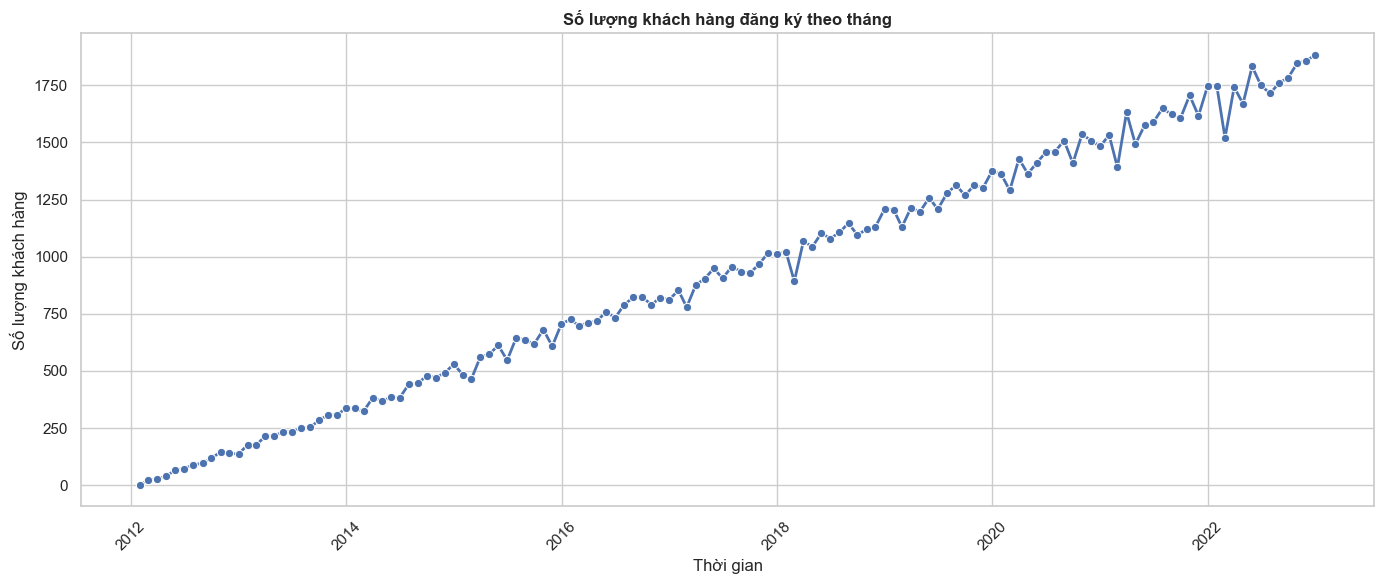

In [18]:
monthly_signup = (
    customers_df
    .set_index('signup_date')
    .resample('ME')
    .size()
    .reset_index(name='signup_count')
)

peak_row = monthly_signup.loc[monthly_signup['signup_count'].idxmax()]
lowest_row = monthly_signup.loc[monthly_signup['signup_count'].idxmin()]

print(
    f"Thang cao nhat: {peak_row['signup_date'].strftime('%Y-%m')} "
    f"voi {peak_row['signup_count']:,} khach hang"
)
print(
    f"Thang thap nhat: {lowest_row['signup_date'].strftime('%Y-%m')} "
    f"voi {lowest_row['signup_count']:,} khach hang"
)

def plot_signup_trend(data, save_path=None):
    plt.figure(figsize=(14, 6))
    ax = sns.lineplot(
        data=data,
        x='signup_date',
        y='signup_count',
        marker='o',
        linewidth=2
    )
    ax.set_title('Số lượng khách hàng đăng ký theo tháng', fontweight='bold')
    ax.set_xlabel('Thời gian')
    ax.set_ylabel('Số lượng khách hàng')
    plt.xticks(rotation=45)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do xu huong tai: {save_path}')

    plt.show()

plot_signup_trend(
    monthly_signup,
    save_path=IMAGES_DIR / 'customers_signup_trend.png'
)

Nhận xét:

- Quan sát:
  - Chuỗi thời gian số khách hàng đăng ký theo tháng tăng gần như liên tục trong giai đoạn từ 2012-01 đến 2022-12.
  - Mức thấp nhất xuất hiện ở 2012-01 với 2 khách hàng, còn mức cao nhất là 2022-12 với 1,883 khách hàng.
  - Dao động ngắn hạn theo tháng có xuất hiện, nhưng biên độ dao động nhỏ hơn nhiều so với xu hướng tăng dài hạn; không thấy giai đoạn sụt giảm kéo dài hoặc đứt gãy cấu trúc rõ rệt.

- Insights:
  - Tăng trưởng acquisition là mô thức nổi bật nhất của tập khách hàng này, quan trọng hơn nhiều so với dao động ngắn hạn theo mùa.
  - Khi so sánh hành vi mua hàng hoặc retention theo thời điểm đăng ký, nên chuẩn hóa theo cohort vì các cohort mới có quy mô lớn hơn đáng kể so với các cohort đầu kỳ.
  - Đà tăng đều qua nhiều năm cho thấy kênh thu hút khách hàng đã được mở rộng khá bền vững, đặc biệt từ khoảng 2018 trở đi.

### 1.1.3. Biến phân loại (Categorical)

In [20]:
COL_INFO = {
    'city': {'name': 'Thành phố', 'unit': 'thanh pho'},
    'gender': {'name': 'Giới tính', 'unit': 'khach hang'},
    'age_group': {'name': 'Nhóm tuổi', 'unit': 'khach hang'},
    'acquisition_channel': {'name': 'Kênh thu hút', 'unit': 'khach hang'}
}

def plot_horizontal_bar_chart(df, cate_cols_names, save_path=None):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]

        if col_name in df.columns:
            val_counts = df[col_name].value_counts()

            if len(val_counts) > 10:
                top9 = val_counts.iloc[:9]
                other_sum = val_counts.iloc[9:].sum()
                plot_data = pd.concat([top9, pd.Series({'Khac': other_sum})])
            else:
                plot_data = val_counts

            plot_data.index = plot_data.index.astype(str)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)

            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'nhom'})
            ax.set_title(f"Phân bố - {info['name']}", fontweight='bold')
            ax.set_xlabel(f"Số lượng {info['unit']}")
            ax.set_ylabel(info['name'])

            for idx, value in enumerate(plot_data.values):
                ax.text(value, idx, f" {value:,}", va='center', fontsize=9)
        else:
            ax.set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do categorical tai: {save_path}')

    plt.show()

Da luu bieu do categorical tai: D:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\notebooks\basic eda\images\customers_categorical_plot.png


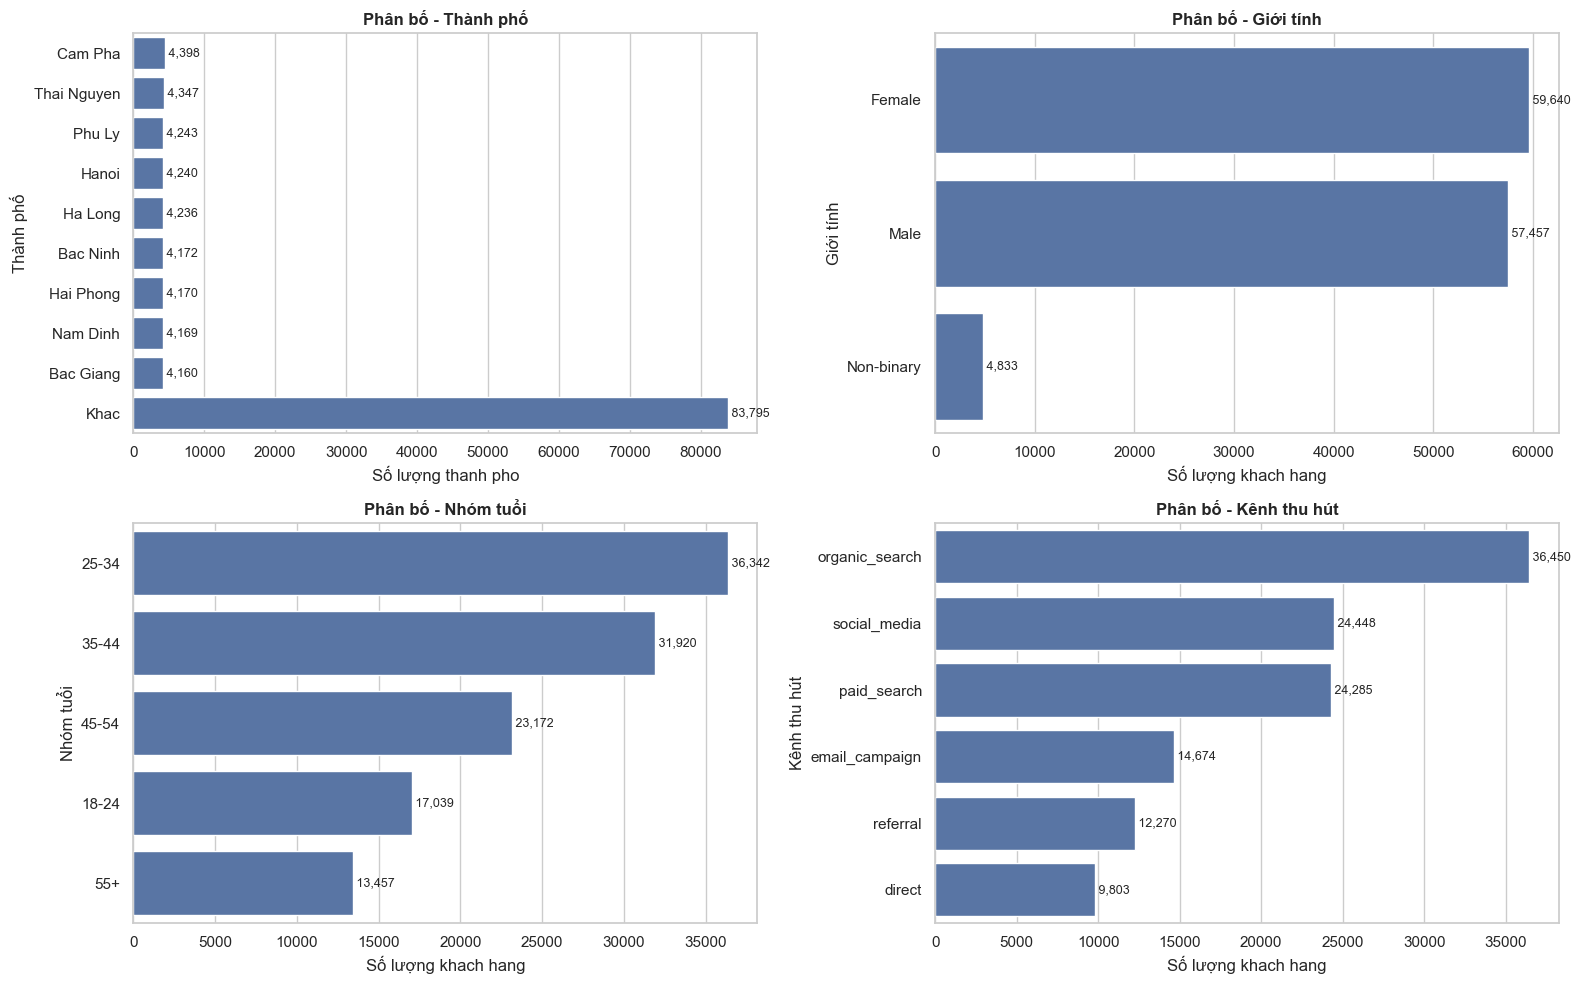

In [21]:
cate_cols = ['city', 'gender', 'age_group', 'acquisition_channel']
plot_horizontal_bar_chart(
    customers_df,
    cate_cols,
    save_path=IMAGES_DIR / 'customers_categorical_plot.png'
)

Nhận xét:

- Quan sát:
  - Thành phố: Không có thành phố nào chi phối mạnh toàn bộ tệp khách hàng. Cam Pha đứng đầu với 4,398 khách hàng (~3.61%), tiếp theo là Thai Nguyen với 4,347 (~3.57%) và Phu Ly với 4,243 (~3.48%). Nhóm `Khác` chiếm 83,795 khách hàng (~68.72%), cho thấy dữ liệu phân tán trên nhiều địa phương.
  - Giới tính: Female có 59,640 khách hàng (~48.91%), Male có 57,457 (~47.12%), còn Non-binary có 4,833 (~3.96%).
  - Nhóm tuổi: `25-34` là nhóm lớn nhất với 36,342 khách hàng (~29.81%), tiếp theo là `35-44` với 31,920 (~26.18%). Nhóm `55+` nhỏ nhất với 13,457 khách hàng (~11.04%).
  - Kênh thu hút: `organic_search` dẫn đầu với 36,450 khách hàng (~29.89%), theo sau là `social_media` (24,448, ~20.05%) và `paid_search` (24,285, ~19.92%). `direct` là kênh nhỏ nhất với 9,803 khách hàng (~8.04%).

- Insights:
  - Tệp khách hàng có độ phủ địa lý khá rộng; để phân tích sâu hoặc mô hình hóa hiệu quả hơn, nên cân nhắc gom `city` theo vùng hoặc kết hợp thêm bảng `geography` để giảm high-cardinality.
  - Phân bố giới tính tương đối cân bằng giữa Female và Male, nên các so sánh theo giới ít bị méo do lệch mẫu quá lớn.
  - Nhóm tuổi trọng tâm nằm ở `25-44`, chiếm khoảng 55.98% tổng khách hàng; đây nhiều khả năng là nhóm persona quan trọng nhất cho các hoạt động marketing và sản phẩm.
  - Cơ cấu acquisition nghiêng mạnh về các kênh discovery và performance (`organic_search`, `social_media`, `paid_search` cộng lại chiếm ~69.86%), trong khi `direct` và `referral` nhỏ hơn, cho thấy nhu cầu chủ động tìm đến thương hiệu chưa phải nguồn chính.

#### a. EDA cột city

In [14]:
customers_df['city'].value_counts()

city
Cam Pha                4398
Thai Nguyen            4347
Phu Ly                 4243
Hanoi                  4240
Ha Long                4236
Bac Ninh               4172
Hai Phong              4170
Nam Dinh               4169
Bac Giang              4160
Ninh Binh              4081
Son Tay                4075
Viet Tri               4054
Uong Bi                4026
Dong Hoi               3912
Kon Tum                3838
Lao Cai                3807
Hoi An                 3760
Phan Thiet             3749
Phan Rang-Thap Cham    3734
Hue                    3719
Tuy Hoa                3674
Quang Ngai             3616
Da Nang                3616
Tam Ky                 3562
Quy Nhon               3556
Nha Trang              3550
Ho Chi Minh City       1359
Vinh Long              1336
Pleiku                 1253
Vung Tau               1251
Da Lat                 1243
Can Tho                1214
Ca Mau                 1211
Bac Lieu               1211
Soc Trang              1208
My Tho         

Nhận xét: Có cột không đồng nhất, không phân bố theo tỉnh

#### b. Cột acquisition_channel

| Giá trị | Ý nghĩa | Ví dụ |
|---|---|---|
| `organic_search` | Khách hàng đến từ tìm kiếm tự nhiên, không trả tiền | Tìm Google “mua giày chạy bộ” rồi vào website |
| `paid_search` | Khách hàng đến từ quảng cáo tìm kiếm có trả phí | Google Ads, Bing Ads |
| `social_media` | Đến từ mạng xã hội | Facebook, Instagram, TikTok, LinkedIn |
| `email_campaign` | Đến từ email marketing | Nhấn link trong email khuyến mãi |
| `referral` | Được giới thiệu từ website khác hoặc người khác | Blog review dẫn link, đối tác giới thiệu |
| `direct` | Truy cập trực tiếp, không có nguồn giới thiệu rõ ràng | Gõ URL thẳng, bookmark |

| Kênh | Số lượng | Ý nghĩa |
|---|---:|---|
| `organic_search` | 36,450 | SEO mạnh, người dùng tự tìm thấy bạn |
| `social_media` | 24,448 | Mạng xã hội hiệu quả |
| `paid_search` | 24,285 | Quảng cáo tìm kiếm đang tạo khách hàng tốt |
| `email_campaign` | 14,674 | Email có tác dụng trung bình |
| `referral` | 12,270 | Có nguồn giới thiệu ổn |
| `direct` | 9,803 | Có nhận diện thương hiệu nhưng chưa quá mạnh |